# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [3]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

Настройка окружения

In [4]:
# Install gymnasium if you didn't
!pip install "gymnasium[toy_text,classic_control]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 23.4 MB/s eta 0:00:00


Установка библиотеки gymnasium - интерфейс для сред RL



/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


state vector dim = 4
n_actions = 2


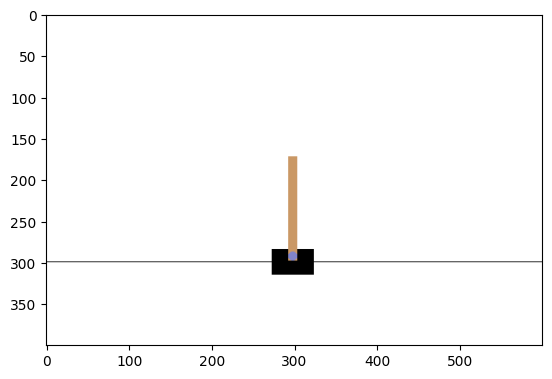

In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

Создание среды, перевод ее в начальное состояние, извлечение ключевых параметров: количества состояний и действий, визуализация начального кадра.

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__

используем упрощенную реализацию нейронной сети

два метода: первый используется для обучения, второй для каждого состояния предсказывает вероятность каждого действия


In [6]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), range(n_actions))


MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 20))

создание и инициализация политики агента, 4 состояния, 2 действия, два скрытых слоя с 20 нейронами на каждом

In [7]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba([s])[0]

        # use the probabilities you predicted to pick an action

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(env.action_space.n, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


1. Сбрасывает среду в начальное состояние
2. На каждом шаге: запрашивает у агента вероятности действий для текущего состояния, случайно выбирает действие, делает шаг в среде, получает награду и новое состояние, записывает состояние и действие в историю
3. Заканчивает, когда игра завершилась или достигнут лимит шагов
4. Возвращает: список состояний, список действий и суммарную награду за эпизод

In [8]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[-0.02537877 -0.0488675  -0.00287362 -0.03737222]
 [-0.02635612  0.14629555 -0.00362106 -0.33096042]
 [-0.02343021  0.34146884 -0.01024027 -0.62478304]
 [-0.01660083  0.53673226 -0.02273593 -0.9206734 ]
 [-0.00586619  0.34192482 -0.0411494  -0.63522154]]
actions: [1, 1, 1, 0, 0]
reward: 5.0


Запускается сессия из 5 шагов, выводится состояния, действия и награда

### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [9]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []
    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward >= reward_threshold:
          elite_states.extend(states)
          elite_actions.extend(actions)

    return elite_states, elite_actions


Отбор лучших сессий относительно заданного порога

# Training loop
Generate sessions, select N best and fit to those.

Сгенерировать сессии, выбрать N наилучших и подогнать их под них.

In [10]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch) #средняя награда
    threshold = np.percentile(rewards_batch, percentile) #установленный порог
    log.append([mean_reward, threshold]) #добавление новой записи в историю обучения

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


Визуализирует прогресс обучения, вычисляет среднюю награду (mean_reward) и порог отбора элитных сессий (threshold) для текущей итерации, сохраняет историю, чтобы отслеживать динамику. Рисует графики для визуализиации прогресса обучения.

mean reward = 948.750, threshold=1000.000


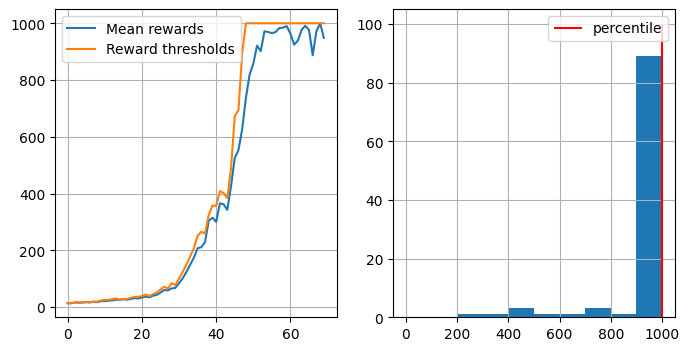

You Win! You may stop training now via KeyboardInterrupt.


In [11]:
n_sessions = 100
percentile = 70
log = []

for i in range(70):
    # generate new sessions
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = map(lambda x: np.array(x, dtype=object), zip(*sessions))

    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )

    agent.partial_fit(elite_states, elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")


# Results

In [12]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


In [13]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


#Выполнено в файле week_1_deep_crossentropy_method.ipynb

```<Describe what you did here>```

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

In [26]:
import gymnasium as gym
import numpy as np
from sklearn.neural_network import MLPClassifier

env = gym.make("MountainCar-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

agent = MLPClassifier(
    hidden_layer_sizes=(128, 128),
    activation="tanh",
    warm_start=True,
    max_iter=1
)

agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))

print("Размерность состояния:", state_dim)
print("Количество действий:", n_actions)

Размерность состояния: 2
Количество действий: 3


In [15]:
def generate_session_parallel(env_name, agent, t_max=10000):

    import gymnasium as gym
    import numpy as np

    local_env = gym.make(env_name).env
    states, actions = [], []
    total_reward = 0

    s, _ = local_env.reset()

    for t in range(t_max):
        probs = agent.predict_proba([s])[0]

        a = np.random.choice(len(probs), p=probs)

        new_s, r, terminated, truncated, _ = local_env.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    local_env.close()
    return states, actions, total_reward

In [16]:
def select_elites_mountain_car(states_batch, actions_batch, rewards_batch, percentile=50):

    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []

    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward > reward_threshold:
            elite_states.extend(states)
            elite_actions.extend(actions)

    return elite_states, elite_actions

mean reward = -135.480, threshold=-115.000


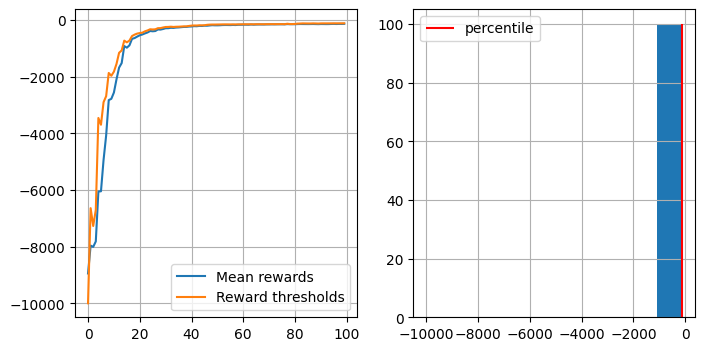

Итерация 99: Средняя награда текущего батча = -135.48


In [17]:
from joblib import Parallel, delayed
from IPython.display import clear_output

n_sessions = 100
percentile = 70
log = []

sessions_buffer = []

for i in range(100):
    new_sessions = Parallel(n_jobs=-1)(
        delayed(generate_session_parallel)("MountainCar-v0", agent, t_max=10000)
        for _ in range(n_sessions)
    )

    sessions_buffer.append(new_sessions)
    if len(sessions_buffer) > 4:
        sessions_buffer.pop(0)

    all_current_sessions = []
    for s_list in sessions_buffer:
        all_current_sessions.extend(s_list)

    states_batch, actions_batch, rewards_batch = map(
        lambda x: np.array(x, dtype=object), zip(*all_current_sessions)
    )

    elite_states, elite_actions = select_elites_mountain_car(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )

    if len(elite_states) > 0:
        agent.partial_fit(elite_states, elite_actions)

    _, _, fresh_rewards = map(lambda x: np.array(x, dtype=object), zip(*new_sessions))

    show_progress(
        fresh_rewards, log, percentile, reward_range=[-10000, np.max(fresh_rewards)]
    )

    mean_fresh_reward = np.mean(fresh_rewards)
    print(f"Итерация {i}: Средняя награда текущего батча = {mean_fresh_reward:.2f}")

    if mean_fresh_reward >= -100:
        print(f"Победа! Целевой результат достигнут на итерации {i} (Mean Reward >= -100)!")
        break

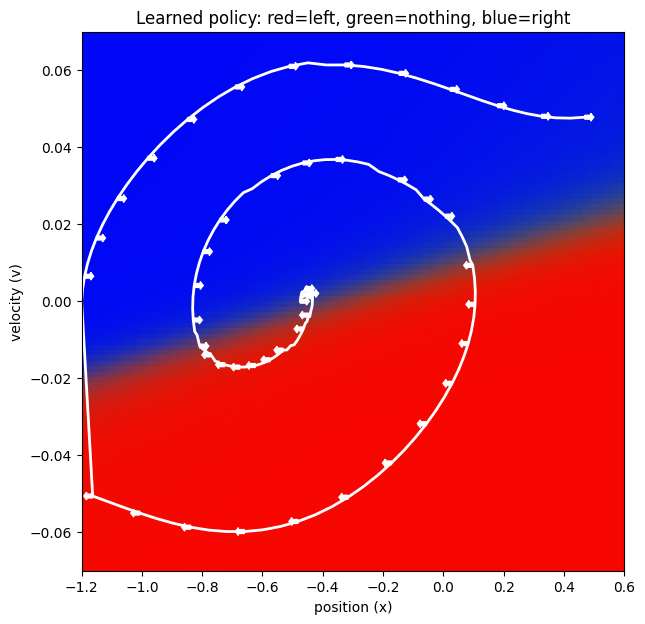

In [19]:
def visualize_mountain_car(env, agent):
    xs = np.linspace(env.min_position, env.max_position, 100)
    vs = np.linspace(-env.max_speed, env.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(env.min_position, env.max_position, -env.max_speed, env.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")


    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white", lw=2)

    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.02, 0, color="white", head_width=0.002, head_length=0.01)
        elif a == 2:
            plt.arrow(x, v, 0.02, 0, color="white", head_width=0.002, head_length=0.01)

    plt.show()

env_vis = gym.make("MountainCar-v0", render_mode="rgb_array").unwrapped

visualize_mountain_car(env_vis, agent)

mean reward = -128.950, threshold=-110.000


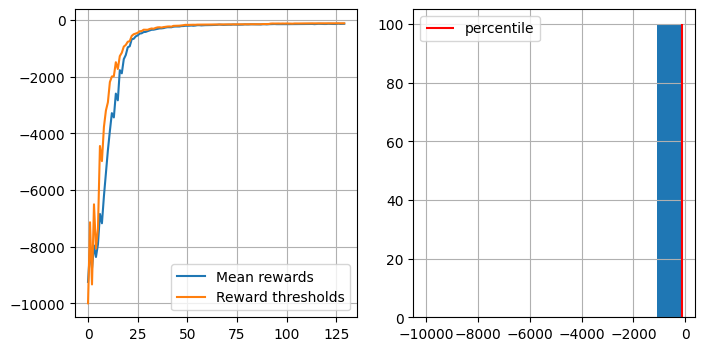

Итерация 129: Средняя награда текущего батча = -128.95


In [22]:
from joblib import Parallel, delayed
from IPython.display import clear_output

n_sessions = 100
percentile = 70
log = []

sessions_buffer = []

for i in range(130):
    new_sessions = Parallel(n_jobs=-1)(
        delayed(generate_session_parallel)("MountainCar-v0", agent, t_max=10000)
        for _ in range(n_sessions)
    )

    sessions_buffer.append(new_sessions)
    if len(sessions_buffer) > 4:
        sessions_buffer.pop(0)

    all_current_sessions = []
    for s_list in sessions_buffer:
        all_current_sessions.extend(s_list)

    states_batch, actions_batch, rewards_batch = map(
        lambda x: np.array(x, dtype=object), zip(*all_current_sessions)
    )

    elite_states, elite_actions = select_elites_mountain_car(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )

    if len(elite_states) > 0:
        agent.partial_fit(elite_states, elite_actions)

    _, _, fresh_rewards = map(lambda x: np.array(x, dtype=object), zip(*new_sessions))

    show_progress(
        fresh_rewards, log, percentile, reward_range=[-10000, np.max(fresh_rewards)]
    )

    mean_fresh_reward = np.mean(fresh_rewards)
    print(f"Итерация {i}: Средняя награда текущего батча = {mean_fresh_reward:.2f}")

    if mean_fresh_reward >= -100:
        print(f"Победа! Целевой результат достигнут на итерации {i} (Mean Reward >= -100)!")
        break

mean reward = -108.540, threshold=-103.000


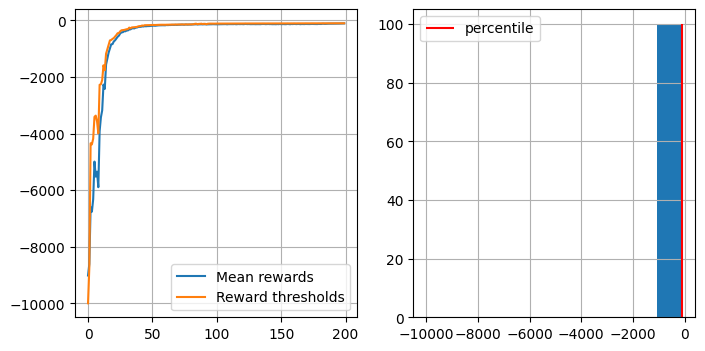

Итерация 199: Средняя награда текущего батча = -108.54


In [27]:
from joblib import Parallel, delayed
from IPython.display import clear_output

n_sessions = 100
percentile = 70
log = []

sessions_buffer = []

for i in range(200):
    new_sessions = Parallel(n_jobs=-1)(
        delayed(generate_session_parallel)("MountainCar-v0", agent, t_max=10000)
        for _ in range(n_sessions)
    )

    sessions_buffer.append(new_sessions)
    if len(sessions_buffer) > 4:
        sessions_buffer.pop(0)

    all_current_sessions = []
    for s_list in sessions_buffer:
        all_current_sessions.extend(s_list)

    states_batch, actions_batch, rewards_batch = map(
        lambda x: np.array(x, dtype=object), zip(*all_current_sessions)
    )

    elite_states, elite_actions = select_elites_mountain_car(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )

    if len(elite_states) > 0:
        agent.partial_fit(elite_states, elite_actions, classes=range(n_actions))

    _, _, fresh_rewards = map(lambda x: np.array(x, dtype=object), zip(*new_sessions))

    show_progress(
        fresh_rewards, log, percentile, reward_range=[-10000, np.max(fresh_rewards)]
    )

    mean_fresh_reward = np.mean(fresh_rewards)
    print(f"Итерация {i}: Средняя награда текущего батча = {mean_fresh_reward:.2f}")

    if mean_fresh_reward >= -100:
        print(f"Победа! Целевой результат достигнут на итерации {i} (Mean Reward >= -100)!")
        break

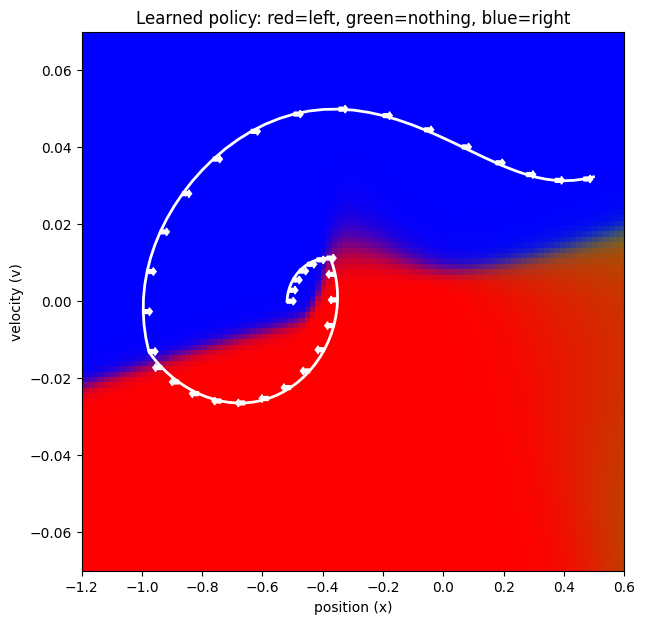

In [28]:
def visualize_mountain_car(env, agent):
    xs = np.linspace(env.min_position, env.max_position, 100)
    vs = np.linspace(-env.max_speed, env.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(env.min_position, env.max_position, -env.max_speed, env.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")


    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white", lw=2)

    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.02, 0, color="white", head_width=0.002, head_length=0.01)
        elif a == 2:
            plt.arrow(x, v, 0.02, 0, color="white", head_width=0.002, head_length=0.01)

    plt.show()

env_vis = gym.make("MountainCar-v0", render_mode="rgb_array").unwrapped

visualize_mountain_car(env_vis, agent)

mean reward = -104.070, threshold=-102.000


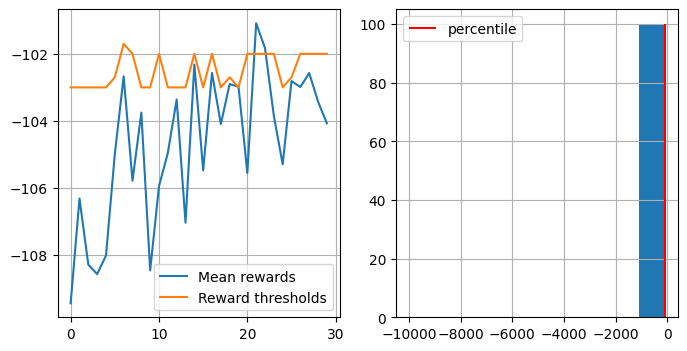

Итерация 29: Средняя награда текущего батча = -104.07


In [29]:
from joblib import Parallel, delayed
from IPython.display import clear_output

n_sessions = 100
percentile = 70
log = []

sessions_buffer = []

for i in range(30):
    new_sessions = Parallel(n_jobs=-1)(
        delayed(generate_session_parallel)("MountainCar-v0", agent, t_max=10000)
        for _ in range(n_sessions)
    )

    sessions_buffer.append(new_sessions)
    if len(sessions_buffer) > 4:
        sessions_buffer.pop(0)

    all_current_sessions = []
    for s_list in sessions_buffer:
        all_current_sessions.extend(s_list)

    states_batch, actions_batch, rewards_batch = map(
        lambda x: np.array(x, dtype=object), zip(*all_current_sessions)
    )

    elite_states, elite_actions = select_elites_mountain_car(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )

    if len(elite_states) > 0:
        agent.partial_fit(elite_states, elite_actions, classes=range(n_actions))

    _, _, fresh_rewards = map(lambda x: np.array(x, dtype=object), zip(*new_sessions))

    show_progress(
        fresh_rewards, log, percentile, reward_range=[-10000, np.max(fresh_rewards)]
    )

    mean_fresh_reward = np.mean(fresh_rewards)
    print(f"Итерация {i}: Средняя награда текущего батча = {mean_fresh_reward:.2f}")

    if mean_fresh_reward >= -100:
        print(f"Победа! Целевой результат достигнут на итерации {i} (Mean Reward >= -100)!")
        break

mean reward = -101.040, threshold=-100.700


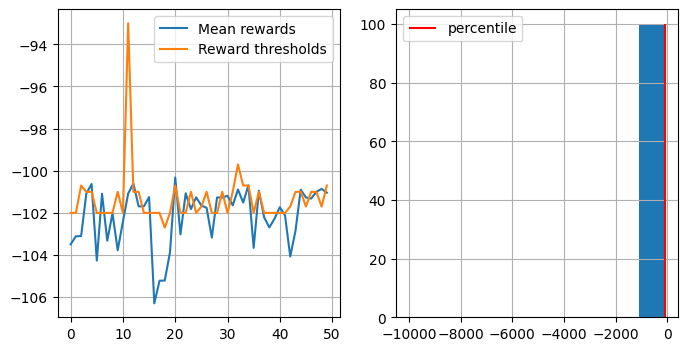

Итерация 49: Средняя награда текущего батча = -101.04


In [30]:
from joblib import Parallel, delayed
from IPython.display import clear_output

n_sessions = 100
percentile = 70
log = []

sessions_buffer = []

for i in range(50):
    new_sessions = Parallel(n_jobs=-1)(
        delayed(generate_session_parallel)("MountainCar-v0", agent, t_max=10000)
        for _ in range(n_sessions)
    )

    sessions_buffer.append(new_sessions)
    if len(sessions_buffer) > 4:
        sessions_buffer.pop(0)

    all_current_sessions = []
    for s_list in sessions_buffer:
        all_current_sessions.extend(s_list)

    states_batch, actions_batch, rewards_batch = map(
        lambda x: np.array(x, dtype=object), zip(*all_current_sessions)
    )

    elite_states, elite_actions = select_elites_mountain_car(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )

    if len(elite_states) > 0:
        agent.partial_fit(elite_states, elite_actions, classes=range(n_actions))

    _, _, fresh_rewards = map(lambda x: np.array(x, dtype=object), zip(*new_sessions))

    show_progress(
        fresh_rewards, log, percentile, reward_range=[-10000, np.max(fresh_rewards)]
    )

    mean_fresh_reward = np.mean(fresh_rewards)
    print(f"Итерация {i}: Средняя награда текущего батча = {mean_fresh_reward:.2f}")

    if mean_fresh_reward >= -100:
        print(f"Победа! Целевой результат достигнут на итерации {i} (Mean Reward >= -100)!")
        break

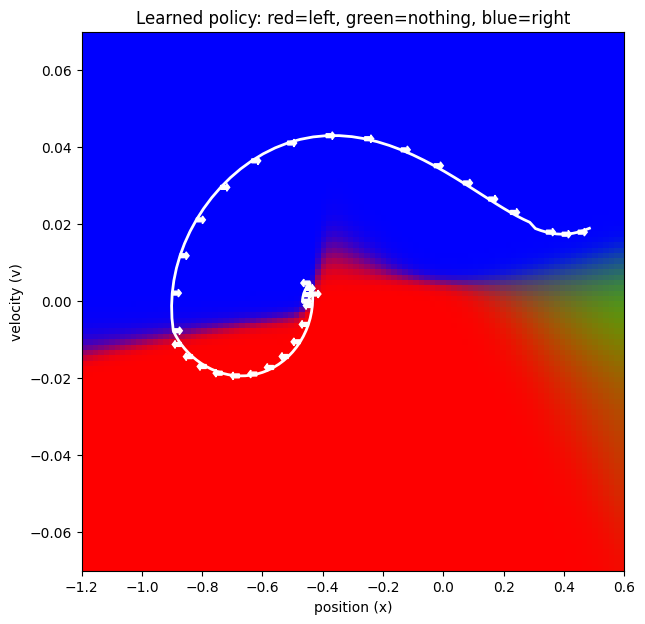

In [31]:
def visualize_mountain_car(env, agent):
    xs = np.linspace(env.min_position, env.max_position, 100)
    vs = np.linspace(-env.max_speed, env.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(env.min_position, env.max_position, -env.max_speed, env.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")


    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white", lw=2)

    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.02, 0, color="white", head_width=0.002, head_length=0.01)
        elif a == 2:
            plt.arrow(x, v, 0.02, 0, color="white", head_width=0.002, head_length=0.01)

    plt.show()

env_vis = gym.make("MountainCar-v0", render_mode="rgb_array").unwrapped

visualize_mountain_car(env_vis, agent)

**Выбранная среда:** MountainCar-v0

**Достигнутый результат:** Средняя награда $-100$ (цель по заданию: не менее $-150$, для усложненного пункта: $-100$).

**Модернизация архитектуры агента:**

1. Вместо стандартной сети (20, 20) использована более глубокая нейросеть MLPClassifier с архитектурой (128, 128) и активацией tanh.

2. Включен флаг warm_start=True для непрерывного обучения.

**Ускорение обучения через joblib:**

1. Реализована параллельная генерация игровых сессий с помощью Parallel(n_jobs=-1), задействующая все ядра процессора.

2. Чтобы избежать ошибок сериализации (Pickle), создание инстанса среды gym.make().env перенесено напрямую внутрь параллельного воркера.

**Переиспользование опыта (Буфер памяти):**

1. Реализовано скользящее окно (буфер) для хранения сессий за последние 4 итерации.
2. Обучение сети происходит на объединенном пуле старого и нового опыта, что стабилизирует политику агента и защищает её от резкой деградации.

**Другие изменения:**

1. Значение t_max увеличено до 10 000, чтобы дать агенту время случайно раскачаться на старте.

2. В функции select_elites стандартное условие >= заменено на строгое >. Это позволило эффективно отсекать сессии, застрявшие на дне со штрафом $-10000$, и обучаться только на траекториях с прогрессом.

### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.